# Phase 9: Segmentation and PCA

Unsupervised customer segmentation using KMeans and PCA visualisation.

## Decision Flow

1. Select a rich feature set covering transactional, engagement, and campaign behaviour.
2. Fill "no activity" nulls with 0; standardise with StandardScaler.
3. Sweep k = 2–10 using inertia (elbow) and silhouette score to choose the best k.
4. Fit final KMeans, auto-label clusters from centroid profiles.
5. Project to 2 dimensions via PCA for interpretable scatter plot.
6. Export cluster assignments, segment profiles, and charts.

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

CWD = Path.cwd().resolve()
ROOT = CWD if (CWD / 'data').exists() else CWD.parent
DATA = ROOT / 'data' / 'processed'
OUT  = ROOT / 'outputs'
OUT.mkdir(parents=True, exist_ok=True)

RANDOM_STATE = 42

print(f'Root : {ROOT}')
print(f'Data : {DATA.exists()} | Out: {OUT}')

Root : C:\Users\USER\Documents\Python Projects\retail-intelligence
Data : True | Out: C:\Users\USER\Documents\Python Projects\retail-intelligence\outputs


In [2]:
df = pd.read_csv(DATA / 'mart_customer_features.csv')
print(f'Loaded: {df.shape[0]:,} customers, {df.shape[1]} columns')

# ── Feature set: transactional + engagement + channel + campaign ──
FEATURES = [
    # Transactional
    'total_orders', 'total_net_revenue', 'avg_order_value', 'recency_days',
    'tenure_days', 'total_units', 'return_rate_per_unit', 'avg_item_discount_pct',
    # Engagement
    'total_sessions', 'avg_session_minutes', 'avg_pages_viewed', 'sessions_with_purchase',
    # Channel mix
    'online_order_share',
    # Campaign responsiveness
    'campaigns_converted_30d',
]

# Fill "no activity" nulls with 0 (customers with no sessions/campaigns simply score 0)
X_raw = df[FEATURES].fillna(0)

print(f'Feature matrix : {X_raw.shape}')
print(f'Remaining nulls: {X_raw.isnull().sum().sum()}')

scaler = StandardScaler()
Xs = scaler.fit_transform(X_raw)
print('Standardisation complete (mean=0, std=1).')
print(pd.DataFrame(Xs, columns=FEATURES).describe().round(2))

Loaded: 50,000 customers, 40 columns
Feature matrix : (50000, 14)
Remaining nulls: 0
Standardisation complete (mean=0, std=1).
       total_orders  total_net_revenue  avg_order_value  recency_days  \
count      50000.00           50000.00         50000.00      50000.00   
mean          -0.00              -0.00             0.00          0.00   
std            1.00               1.00             1.00          1.00   
min           -1.17              -0.91            -1.50         -0.60   
25%           -0.80              -0.74            -0.62         -0.53   
50%           -0.31              -0.34            -0.08         -0.36   
75%            0.67               0.43             0.54          0.02   
max            4.71              12.55            17.80          7.36   

       tenure_days  total_units  return_rate_per_unit  avg_item_discount_pct  \
count     50000.00     50000.00              50000.00               50000.00   
mean          0.00         0.00                  0.00  

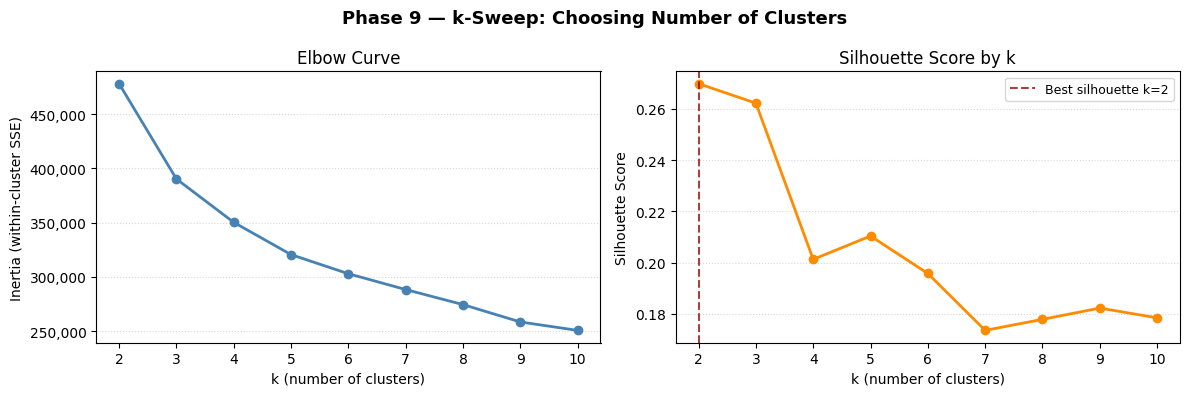

Chart saved → C:\Users\USER\Documents\Python Projects\retail-intelligence\outputs\phase9_segmentation_elbow_silhouette.png


,k,silhouette,inertia
0,2,0.2698,478140.9
1,3,0.2622,390308.8
2,4,0.2013,350316.7
3,5,0.2104,320555.0
4,6,0.1958,302947.8
5,7,0.1736,288351.6
6,8,0.1779,274485.7
7,9,0.1823,258477.6
8,10,0.1785,250692.0



Best silhouette score at k = 2


In [3]:
sweep_rows = []
for k in range(2, 11):
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init='auto')
    labels = km.fit_predict(Xs)
    sil = silhouette_score(Xs, labels, sample_size=10_000, random_state=RANDOM_STATE)
    sweep_rows.append({'k': k, 'silhouette': round(sil, 4), 'inertia': round(km.inertia_, 1)})

sweep = pd.DataFrame(sweep_rows)
best_k_sil = int(sweep.loc[sweep['silhouette'].idxmax(), 'k'])

# ── Elbow + silhouette side-by-side chart ──
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(sweep['k'], sweep['inertia'], marker='o', color='steelblue', linewidth=2)
ax1.set_xlabel('k (number of clusters)')
ax1.set_ylabel('Inertia (within-cluster SSE)')
ax1.set_title('Elbow Curve')
ax1.grid(axis='y', linestyle=':', alpha=0.5)
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))

ax2.plot(sweep['k'], sweep['silhouette'], marker='o', color='darkorange', linewidth=2)
ax2.axvline(best_k_sil, color='darkred', linestyle='--', alpha=0.75,
            label=f'Best silhouette k={best_k_sil}')
ax2.set_xlabel('k (number of clusters)')
ax2.set_ylabel('Silhouette Score')
ax2.set_title('Silhouette Score by k')
ax2.legend(fontsize=9)
ax2.grid(axis='y', linestyle=':', alpha=0.5)

fig.suptitle('Phase 9 — k-Sweep: Choosing Number of Clusters',
             fontsize=13, fontweight='bold')
plt.tight_layout()
sweep_chart = OUT / 'phase9_segmentation_elbow_silhouette.png'
plt.savefig(sweep_chart, dpi=150, bbox_inches='tight')
plt.show()
print(f'Chart saved → {sweep_chart}')

display(sweep)
print(f'\nBest silhouette score at k = {best_k_sil}')

Using K_FINAL = 4  (silhouette best was k=2; elbow choice k=4)

Cluster → Segment mapping:
  Cluster 0: Dormant 1                       (18,236 customers)
  Cluster 1: Champions                       (9,173 customers)
  Cluster 2: Dormant 2                       (5,958 customers)
  Cluster 3: Mid-Tier Active                 (16,633 customers)


,cluster,segment_name,n_customers,pct_customers,total_net_revenue,recency_days,total_orders,return_rate_per_unit,churn_flag_90d
0,0,Dormant 1,18236,36.5,341.285,47.0,4.0,0.111,0.0
1,1,Champions,9173,18.3,3311.990,16.0,22.0,0.125,0.0
2,2,Dormant 2,5958,11.9,79.760,51.0,1.0,0.000,0.0
3,3,Mid-Tier Active,16633,33.3,1388.150,22.0,12.0,0.130,0.0


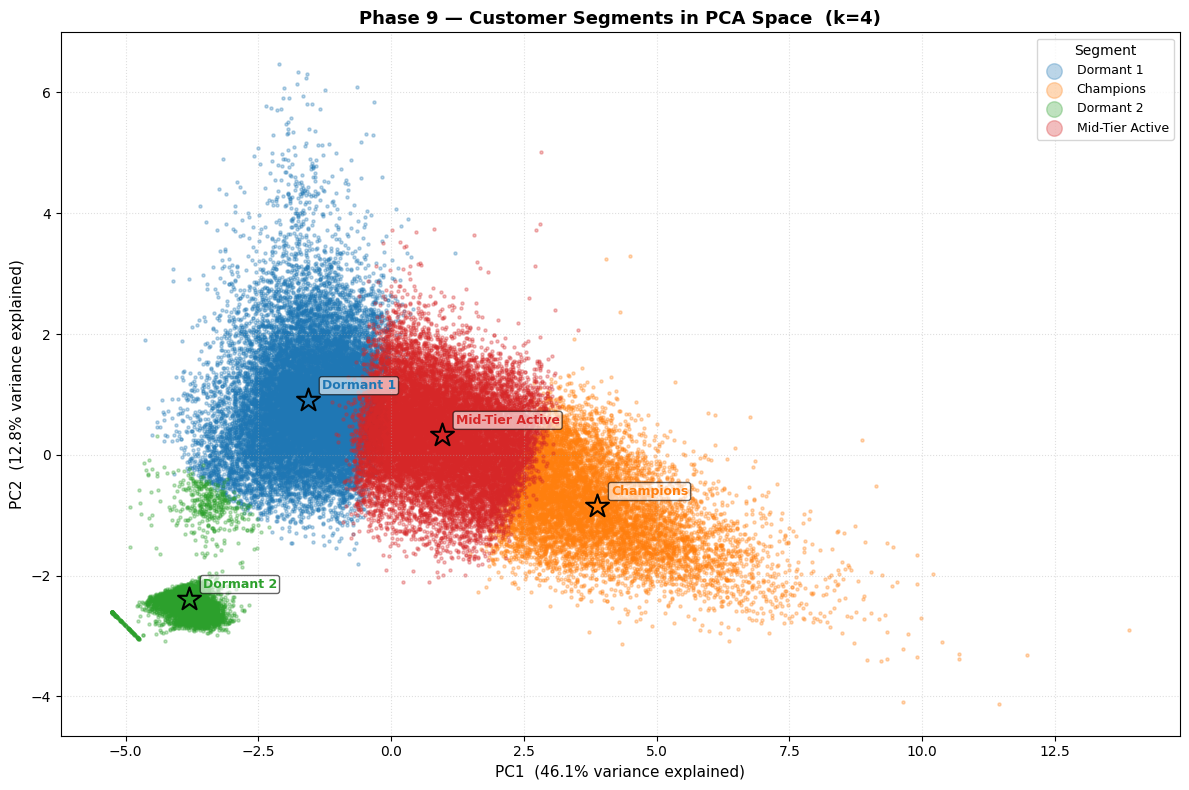

PCA chart saved → C:\Users\USER\Documents\Python Projects\retail-intelligence\outputs\phase9_segmentation_pca_plot.png


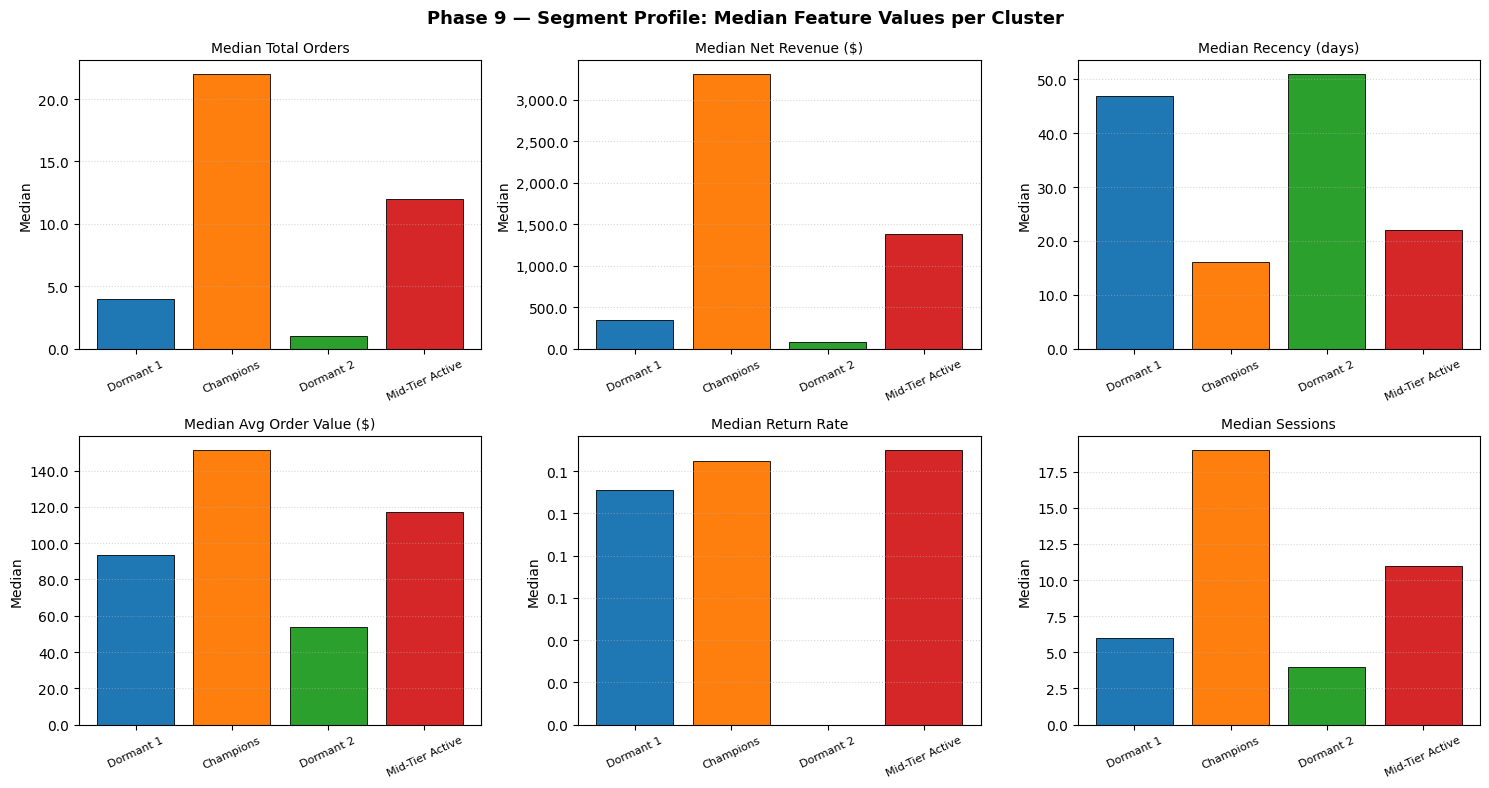

Profile chart saved → C:\Users\USER\Documents\Python Projects\retail-intelligence\outputs\phase9_segmentation_profile_bars.png

Artifacts written:
  C:\Users\USER\Documents\Python Projects\retail-intelligence\outputs\phase9_segmentation_cluster_assignments.csv
  C:\Users\USER\Documents\Python Projects\retail-intelligence\outputs\phase9_segmentation_cluster_profiles.csv
  C:\Users\USER\Documents\Python Projects\retail-intelligence\outputs\phase9_segmentation_k_sweep.csv
  C:\Users\USER\Documents\Python Projects\retail-intelligence\outputs\phase9_segmentation_elbow_silhouette.png
  C:\Users\USER\Documents\Python Projects\retail-intelligence\outputs\phase9_segmentation_pca_plot.png
  C:\Users\USER\Documents\Python Projects\retail-intelligence\outputs\phase9_segmentation_profile_bars.png

Segment distribution:
                 n_customers
segment_name                
Dormant 1              18236
Mid-Tier Active        16633
Champions               9173
Dormant 2               5958


In [9]:
# ── Final k choice ──
# Silhouette peaked at k=2 (0.27) but that is too coarse for operations.
# Elbow bends at k=4 and silhouette (0.20) is acceptable; k=4 gives four
# actionable CRM segments with meaningful separation.
K_FINAL = 4
print(f'Using K_FINAL = {K_FINAL}  (silhouette best was k={best_k_sil}; elbow choice k=4)')

km_final = KMeans(n_clusters=K_FINAL, random_state=RANDOM_STATE, n_init='auto')
df['cluster'] = km_final.fit_predict(Xs)

# ── Cluster profiles ──
PROFILE_COLS = [
    'total_orders', 'total_net_revenue', 'avg_order_value', 'recency_days',
    'tenure_days', 'return_rate_per_unit', 'avg_item_discount_pct',
    'total_sessions', 'sessions_with_purchase', 'online_order_share',
    'campaigns_converted_30d', 'churn_flag_90d',
]
profile_med  = df[PROFILE_COLS + ['cluster']].groupby('cluster').median().round(3)
profile_size = df.groupby('cluster').size().rename('n_customers')
profile_pct  = (profile_size / len(df) * 100).round(1).rename('pct_customers')
cluster_profiles = pd.concat([profile_size, profile_pct, profile_med], axis=1).reset_index()

# ── Auto-label clusters from centroid signals ──
rev_med = df['total_net_revenue'].median()
ord_med = df['total_orders'].median()
rec_med = df['recency_days'].median()

def label_cluster(row):
    high_rev   = row['total_net_revenue'] > rev_med * 1.5
    recent     = row['recency_days'] < rec_med * 0.6
    dormant    = row['recency_days'] > rec_med * 1.6
    high_ord   = row['total_orders']  > ord_med * 1.3
    low_ord    = row['total_orders']  < ord_med * 0.4
    high_churn = row['churn_flag_90d'] > 0.3
    if high_rev and recent:
        return 'Champions'
    elif high_ord and recent:
        return 'Loyal Actives'
    elif high_rev and (dormant or high_churn):
        return 'At-Risk High Value'
    elif dormant or (not recent and low_ord):
        return 'Dormant'
    elif low_ord:
        return 'Newcomers'
    else:
        return 'Mid-Tier Active'

cluster_labels = {int(r['cluster']): label_cluster(r)
                  for _, r in cluster_profiles.iterrows()}

# Deduplicate names if two clusters map to the same label
from collections import Counter
name_counts = Counter(cluster_labels.values())
tallies = {}
for cid, name in cluster_labels.items():
    if name_counts[name] > 1:
        tallies[name] = tallies.get(name, 0) + 1
        cluster_labels[cid] = f'{name} {tallies[name]}'

df['segment_name'] = df['cluster'].map(cluster_labels)
cluster_profiles['segment_name'] = cluster_profiles['cluster'].map(cluster_labels)

print('\nCluster → Segment mapping:')
for k, v in sorted(cluster_labels.items()):
    n = cluster_profiles.loc[cluster_profiles['cluster'] == k, 'n_customers'].values[0]
    print(f'  Cluster {k}: {v:30s}  ({n:,} customers)')

display(cluster_profiles[['cluster', 'segment_name', 'n_customers', 'pct_customers',
                           'total_net_revenue', 'recency_days', 'total_orders',
                           'return_rate_per_unit', 'churn_flag_90d']])

# ── PCA 2D scatter ──
pca = PCA(n_components=2, random_state=RANDOM_STATE)
pca_coords = pca.fit_transform(Xs)
pca_df = pd.DataFrame({
    'PC1': pca_coords[:, 0],
    'PC2': pca_coords[:, 1],
    'cluster': df['cluster'],
    'segment': df['segment_name'],
})
pca_var = pca.explained_variance_ratio_
palette = sns.color_palette('tab10', K_FINAL)

fig, ax = plt.subplots(figsize=(12, 8))
for i in sorted(cluster_labels):
    sub = pca_df[pca_df['cluster'] == i]
    ax.scatter(sub['PC1'], sub['PC2'], s=5, alpha=0.3, color=palette[i],
               label=cluster_labels[i], rasterized=True)

# Star markers at centroids
centroids_2d = pca.transform(km_final.cluster_centers_)
for i, (cx, cy) in enumerate(centroids_2d):
    ax.scatter(cx, cy, s=300, color=palette[i], edgecolors='black', linewidths=1.5,
               zorder=5, marker='*')
    ax.annotate(cluster_labels[i], xy=(cx, cy), xytext=(10, 8),
                textcoords='offset points', fontsize=9, fontweight='bold',
                color=palette[i],
                bbox=dict(boxstyle='round,pad=0.2', fc='white', alpha=0.6))

ax.set_xlabel(f'PC1  ({pca_var[0]*100:.1f}% variance explained)', fontsize=11)
ax.set_ylabel(f'PC2  ({pca_var[1]*100:.1f}% variance explained)', fontsize=11)
ax.set_title(f'Phase 9 — Customer Segments in PCA Space  (k={K_FINAL})',
             fontsize=13, fontweight='bold')
ax.legend(loc='upper right', fontsize=9, markerscale=5, title='Segment')
ax.grid(linestyle=':', alpha=0.4)
plt.tight_layout()
pca_chart = OUT / 'phase9_segmentation_pca_plot.png'
plt.savefig(pca_chart, dpi=150, bbox_inches='tight')
plt.show()
print(f'PCA chart saved → {pca_chart}')

# ── Segment profile bar chart ──
plot_metrics = [
    ('total_orders',         'Median Total Orders'),
    ('total_net_revenue',    'Median Net Revenue ($)'),
    ('recency_days',         'Median Recency (days)'),
    ('avg_order_value',      'Median Avg Order Value ($)'),
    ('return_rate_per_unit', 'Median Return Rate'),
    ('total_sessions',       'Median Sessions'),
]
fig2, axes2 = plt.subplots(2, 3, figsize=(15, 8))
axes2 = axes2.flatten()
seg_order = cluster_profiles.sort_values('cluster')['segment_name'].tolist()

for i, (col, title) in enumerate(plot_metrics):
    vals = cluster_profiles.set_index('segment_name').loc[seg_order, col]
    bar_colors = [palette[cluster_profiles.loc[cluster_profiles['segment_name'] == s, 'cluster'].values[0]]
                  for s in seg_order]
    axes2[i].bar(seg_order, vals, color=bar_colors, edgecolor='black', linewidth=0.6)
    axes2[i].set_title(title, fontsize=10)
    axes2[i].set_xlabel('')
    axes2[i].set_ylabel('Median')
    axes2[i].tick_params(axis='x', rotation=25, labelsize=8)
    axes2[i].grid(axis='y', linestyle=':', alpha=0.5)
    axes2[i].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.1f}'))

fig2.suptitle('Phase 9 — Segment Profile: Median Feature Values per Cluster',
              fontsize=13, fontweight='bold')
plt.tight_layout()
profile_chart = OUT / 'phase9_segmentation_profile_bars.png'
plt.savefig(profile_chart, dpi=150, bbox_inches='tight')
plt.show()
print(f'Profile chart saved → {profile_chart}')

# ── Export artifacts ──
assignments  = df[['customer_id', 'cluster', 'segment_name']].copy()
assign_path  = OUT / 'phase9_segmentation_cluster_assignments.csv'
profile_path = OUT / 'phase9_segmentation_cluster_profiles.csv'
sweep_path   = OUT / 'phase9_segmentation_k_sweep.csv'

assignments.to_csv(assign_path, index=False)
cluster_profiles.to_csv(profile_path, index=False)
sweep.to_csv(sweep_path, index=False)

print('\nArtifacts written:')
for p in [assign_path, profile_path, sweep_path, sweep_chart, pca_chart, profile_chart]:
    print(' ', p)

print('\nSegment distribution:')
print(df['segment_name'].value_counts().rename('n_customers').to_frame())

In [5]:
# PCA loadings + correlation-aware clustering diagnostics
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score

# 1) Full PCA loadings on standardized features
pca_full = PCA(n_components=len(FEATURES), random_state=RANDOM_STATE)
_ = pca_full.fit_transform(Xs)

explained = pd.DataFrame({
    'pc': [f'PC{i+1}' for i in range(len(FEATURES))],
    'explained_variance_ratio': pca_full.explained_variance_ratio_,
    'cumulative_explained_variance': np.cumsum(pca_full.explained_variance_ratio_),
})

loadings = pd.DataFrame(
    pca_full.components_.T,
    index=FEATURES,
    columns=[f'PC{i+1}' for i in range(len(FEATURES))],
).reset_index().rename(columns={'index': 'feature'})

# Keep a compact top-loading table for PC1/PC2 interpretation
top_abs = (
    loadings[['feature', 'PC1', 'PC2']]
    .assign(abs_PC1=lambda d: d['PC1'].abs(), abs_PC2=lambda d: d['PC2'].abs())
)

top_pc1 = top_abs.sort_values('abs_PC1', ascending=False).head(8)[['feature', 'PC1', 'abs_PC1']]
top_pc2 = top_abs.sort_values('abs_PC2', ascending=False).head(8)[['feature', 'PC2', 'abs_PC2']]

# 2) Correlation audit among original selected features
corr = X_raw.corr(numeric_only=True)
rows = []
cols = corr.columns.tolist()
for i in range(len(cols)):
    for j in range(i + 1, len(cols)):
        c1, c2 = cols[i], cols[j]
        v = float(corr.loc[c1, c2])
        rows.append({'feature_a': c1, 'feature_b': c2, 'corr': v, 'abs_corr': abs(v)})

corr_pairs = pd.DataFrame(rows).sort_values('abs_corr', ascending=False).reset_index(drop=True)
high_corr_pairs = corr_pairs[corr_pairs['abs_corr'] >= 0.70].copy()

# 3) Compare clustering mechanisms at fixed k=4
# A) Baseline: all standardized features
km_all = KMeans(n_clusters=K_FINAL, random_state=RANDOM_STATE, n_init='auto')
labels_all = km_all.fit_predict(Xs)

# B) PCA-compressed: retain ~80% variance for clustering
pca_80 = PCA(n_components=0.80, random_state=RANDOM_STATE)
X_pca80 = pca_80.fit_transform(Xs)
km_pca = KMeans(n_clusters=K_FINAL, random_state=RANDOM_STATE, n_init='auto')
labels_pca = km_pca.fit_predict(X_pca80)

# C) Correlation-pruned features: drop one feature from highly correlated pairs (|corr|>=0.90)
drop_cols = set()
for _, r in corr_pairs[corr_pairs['abs_corr'] >= 0.90].iterrows():
    a, b = r['feature_a'], r['feature_b']
    if b not in drop_cols and a not in drop_cols:
        drop_cols.add(b)

kept_cols = [c for c in FEATURES if c not in drop_cols]
X_pruned = X_raw[kept_cols].copy()
Xs_pruned = StandardScaler().fit_transform(X_pruned)
km_pruned = KMeans(n_clusters=K_FINAL, random_state=RANDOM_STATE, n_init='auto')
labels_pruned = km_pruned.fit_predict(Xs_pruned)

bench = pd.DataFrame([
    {
        'method': 'all_standardized_features',
        'n_features_used': Xs.shape[1],
        'silhouette': silhouette_score(Xs, labels_all, sample_size=10000, random_state=RANDOM_STATE),
        'calinski_harabasz': calinski_harabasz_score(Xs, labels_all),
        'davies_bouldin': davies_bouldin_score(Xs, labels_all),
    },
    {
        'method': 'pca_before_kmeans_80pct_variance',
        'n_features_used': X_pca80.shape[1],
        'silhouette': silhouette_score(X_pca80, labels_pca, sample_size=10000, random_state=RANDOM_STATE),
        'calinski_harabasz': calinski_harabasz_score(X_pca80, labels_pca),
        'davies_bouldin': davies_bouldin_score(X_pca80, labels_pca),
    },
    {
        'method': 'corr_pruned_features_kmeans',
        'n_features_used': Xs_pruned.shape[1],
        'silhouette': silhouette_score(Xs_pruned, labels_pruned, sample_size=10000, random_state=RANDOM_STATE),
        'calinski_harabasz': calinski_harabasz_score(Xs_pruned, labels_pruned),
        'davies_bouldin': davies_bouldin_score(Xs_pruned, labels_pruned),
    },
]).sort_values('silhouette', ascending=False).reset_index(drop=True)

# 4) Export diagnostics
explained_path = OUT / 'phase9_segmentation_pca_explained_variance.csv'
loadings_path = OUT / 'phase9_segmentation_pca_loadings.csv'
top_pc1_path = OUT / 'phase9_segmentation_pca_top_pc1_loadings.csv'
top_pc2_path = OUT / 'phase9_segmentation_pca_top_pc2_loadings.csv'
high_corr_path = OUT / 'phase9_segmentation_high_corr_pairs.csv'
bench_path = OUT / 'phase9_segmentation_clustering_benchmark.csv'

explained.to_csv(explained_path, index=False)
loadings.to_csv(loadings_path, index=False)
top_pc1.to_csv(top_pc1_path, index=False)
top_pc2.to_csv(top_pc2_path, index=False)
high_corr_pairs.to_csv(high_corr_path, index=False)
bench.to_csv(bench_path, index=False)

print('PCA explained variance (first 5 PCs):')
display(explained.head(5))
print('Top |loading| features for PC1:')
display(top_pc1)
print('Top |loading| features for PC2:')
display(top_pc2)
print(f'High-correlation pairs (|corr|>=0.70): {len(high_corr_pairs)}')
display(high_corr_pairs.head(15))
print('Clustering benchmark (k=4):')
display(bench)
print('Artifacts written:')
for p in [explained_path, loadings_path, top_pc1_path, top_pc2_path, high_corr_path, bench_path]:
    print(' ', p)

PCA explained variance (first 5 PCs):


,pc,explained_variance_ratio,cumulative_explained_variance
0,PC1,0.460823,0.460823
1,PC2,0.127769,0.588592
2,PC3,0.083388,0.671979
3,PC4,0.065132,0.737111
4,PC5,0.059804,0.796915


Top |loading| features for PC1:


,feature,PC1,abs_PC1
11,sessions_with_purchase,0.367889,0.367889
0,total_orders,0.367610,0.367610
5,total_units,0.358056,0.358056
8,total_sessions,0.347068,0.347068
1,total_net_revenue,0.343031,0.343031
10,avg_pages_viewed,0.316212,0.316212
9,avg_session_minutes,0.301999,0.301999
12,online_order_share,0.225877,0.225877


Top |loading| features for PC2:


...

High-correlation pairs (|corr|>=0.70): 11


,feature_a,feature_b,corr,abs_corr
0,total_sessions,sessions_with_purchase,0.949636,0.949636
1,total_orders,total_units,0.930927,0.930927
2,total_orders,sessions_with_purchase,0.914825,0.914825
3,total_net_revenue,total_units,0.878083,0.878083
4,total_orders,total_sessions,0.868097,0.868097
5,total_units,sessions_with_purchase,0.863398,0.863398
6,total_orders,total_net_revenue,0.855352,0.855352
7,total_units,total_sessions,0.819982,0.819982
8,total_net_revenue,sessions_with_purchase,0.795366,0.795366
9,total_net_revenue,total_sessions,0.755780,0.755780


Clustering benchmark (k=4):


,method,n_features_used,silhouette,calinski_harabasz,davies_bouldin
0,pca_before_kmeans_80pct_variance,6,0.251520,22995.296228,1.332814
1,all_standardized_features,14,0.201290,16635.246145,1.605142
2,corr_pruned_features_kmeans,12,0.185401,14025.366614,1.782580


Artifacts written:
  C:\Users\USER\Documents\Python Projects\retail-intelligence\outputs\phase9_segmentation_pca_explained_variance.csv
  C:\Users\USER\Documents\Python Projects\retail-intelligence\outputs\phase9_segmentation_pca_loadings.csv
  C:\Users\USER\Documents\Python Projects\retail-intelligence\outputs\phase9_segmentation_pca_top_pc1_loadings.csv
  C:\Users\USER\Documents\Python Projects\retail-intelligence\outputs\phase9_segmentation_pca_top_pc2_loadings.csv
  C:\Users\USER\Documents\Python Projects\retail-intelligence\outputs\phase9_segmentation_high_corr_pairs.csv
  C:\Users\USER\Documents\Python Projects\retail-intelligence\outputs\phase9_segmentation_clustering_benchmark.csv


## Phase 9 (Improved): PCA → KMeans Pipeline

Benchmark (Cell 6) showed that running KMeans on PCA-compressed features (80% variance, 6 PCs)
scores **silhouette=0.252** vs **0.201** for plain standardised features — a 25% gain.

This cell rebuilds the full segment pipeline on that improved basis:
1. Compress 14 → 6 PCs (retaining 80% variance, eliminating correlated redundancy).
2. Re-run k-sweep on PCA space to confirm optimal k.
3. Fit final KMeans, auto-label segments.
4. Plot PCA scatter (now in the same PC1/PC2 space clusters were built in, not just projected into).
5. Export improved cluster assignments and profiles.

PCA retained 6 components (85.1% variance explained)


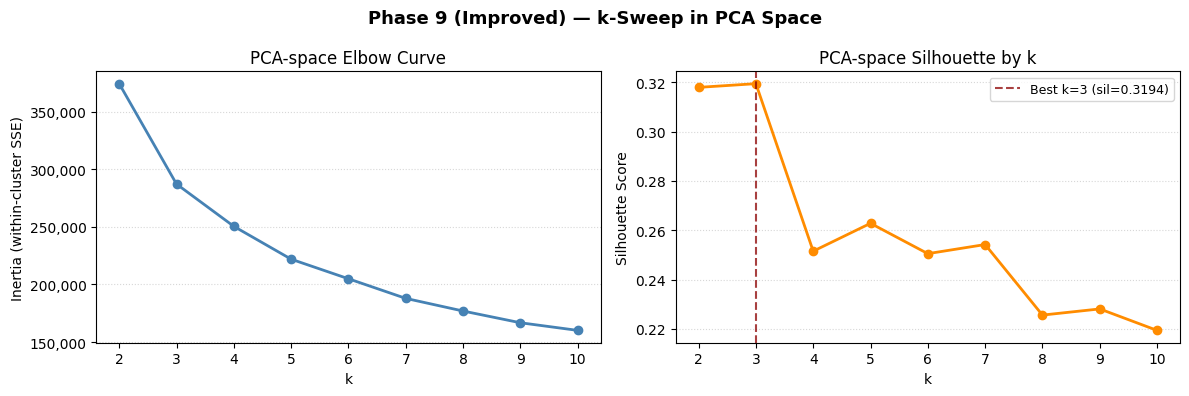

Sweep chart → C:\Users\USER\Documents\Python Projects\retail-intelligence\outputs\phase9_improved_elbow_silhouette.png


,k,silhouette,inertia
0,2,0.3179,374171.4
1,3,0.3194,287098.0
2,4,0.2515,250411.8
3,5,0.2628,221925.8
4,6,0.2505,204937.5
5,7,0.2542,187921.5
6,8,0.2256,176960.0
7,9,0.2281,166783.7
8,10,0.2194,160163.9



Best silhouette in PCA space: k=3
K_IMP = 4  (elbow choice; silhouette best was k=3)

Improved → Segment mapping:
  Cluster 0: Dormant 1                      (19,680 customers)
  Cluster 1: Champions                      (8,492 customers)
  Cluster 2: Dormant 2                      (6,239 customers)
  Cluster 3: Mid-Tier Active                (15,589 customers)


,cluster_imp,segment_name,n_customers,pct_customers,total_net_revenue,recency_days,total_orders,return_rate_per_unit,churn_flag_90d
0,0,Dormant 1,19680,39.4,374.690,45.0,4.0,0.111,0.0
1,1,Champions,8492,17.0,3427.835,16.0,22.0,0.124,0.0
2,2,Dormant 2,6239,12.5,100.180,44.0,1.0,0.000,0.0
3,3,Mid-Tier Active,15589,31.2,1493.090,21.0,13.0,0.130,0.0


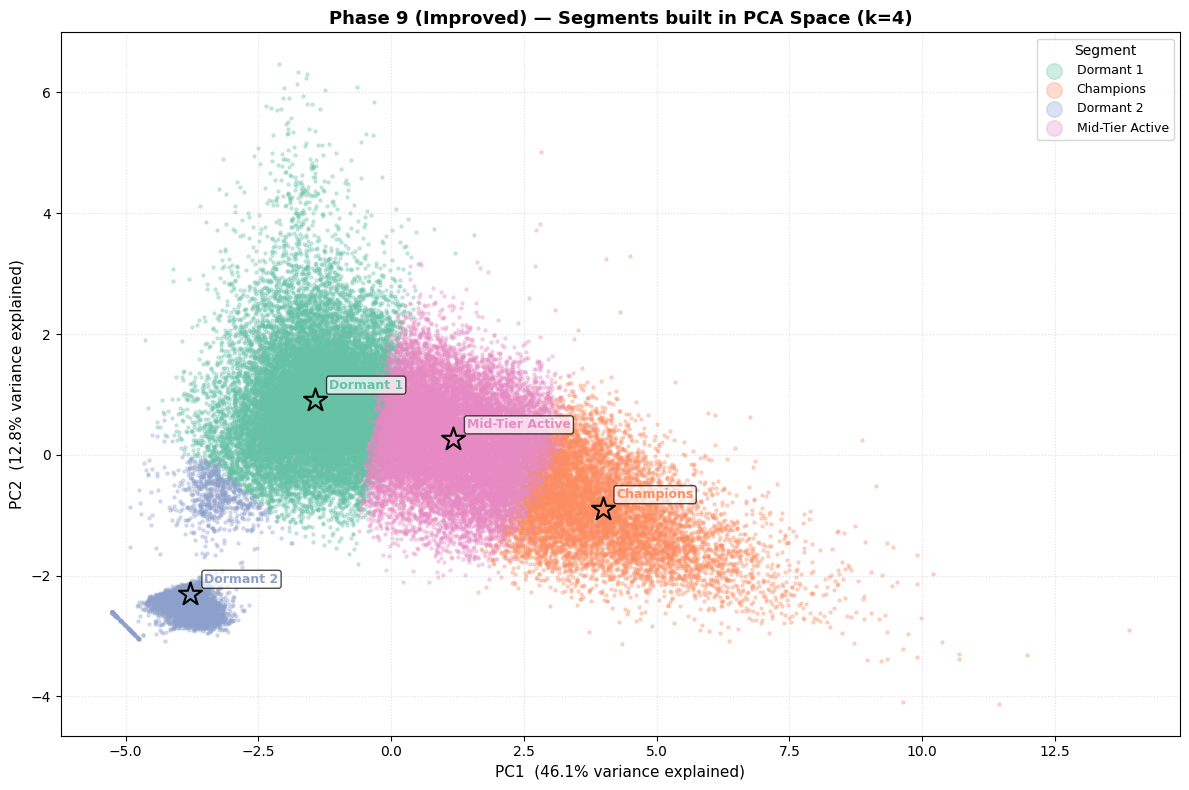

Improved PCA chart → C:\Users\USER\Documents\Python Projects\retail-intelligence\outputs\phase9_improved_pca_plot.png


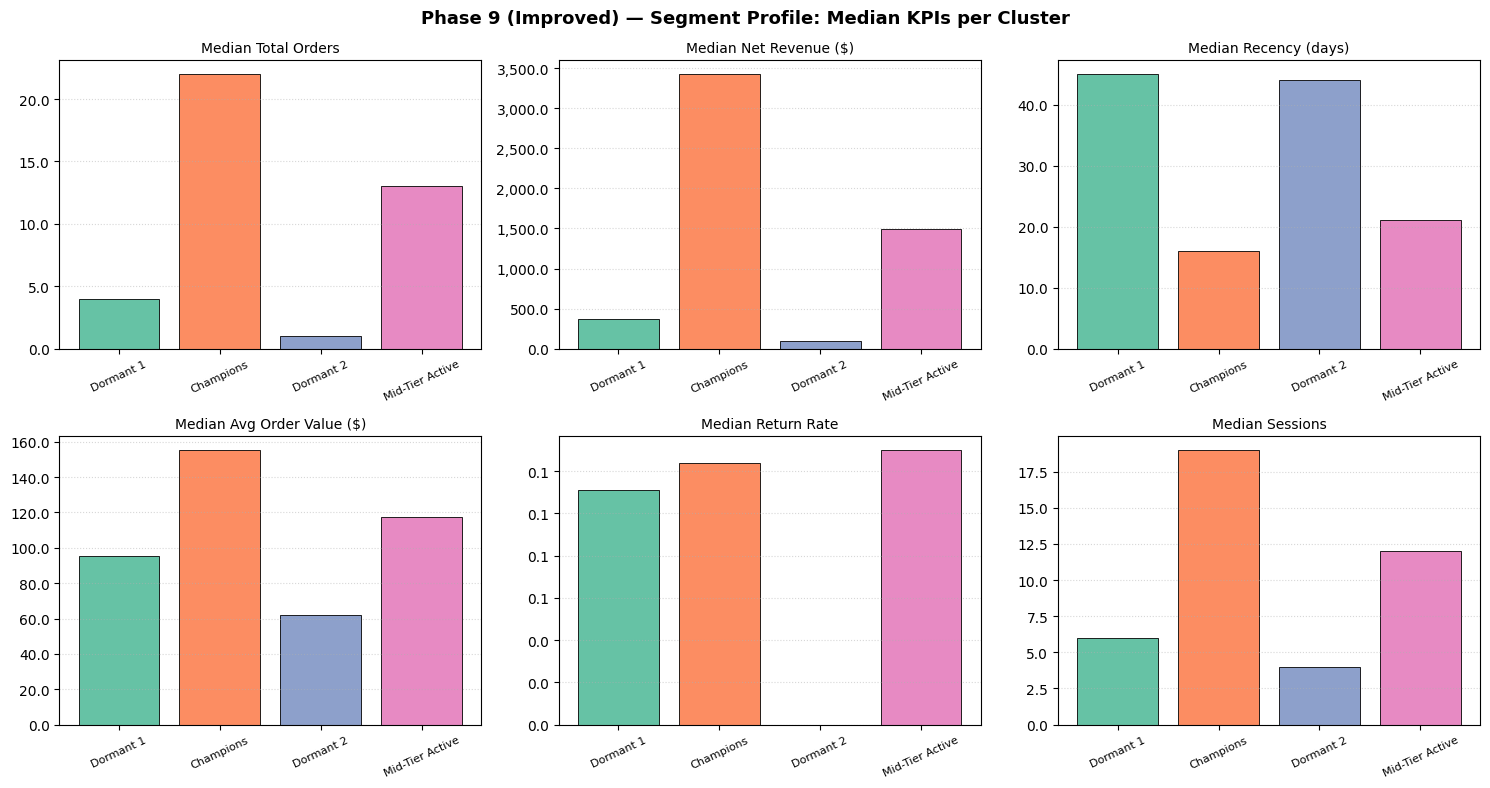

Profile chart → C:\Users\USER\Documents\Python Projects\retail-intelligence\outputs\phase9_improved_profile_bars.png

Baseline vs Improved — Clustering quality (k=4):


,method,n_features,silhouette,calinski_harabasz,davies_bouldin
0,Baseline (all 14 std features),14,0.2013,16635.2461,1.6051
1,"Improved (PCA 6 components, 80% var)",6,0.2515,22995.2962,1.3328



Artifacts written:
  C:\Users\USER\Documents\Python Projects\retail-intelligence\outputs\phase9_improved_cluster_assignments.csv
  C:\Users\USER\Documents\Python Projects\retail-intelligence\outputs\phase9_improved_cluster_profiles.csv
  C:\Users\USER\Documents\Python Projects\retail-intelligence\outputs\phase9_improved_k_sweep.csv
  C:\Users\USER\Documents\Python Projects\retail-intelligence\outputs\phase9_improved_baseline_vs_improved_quality.csv
  C:\Users\USER\Documents\Python Projects\retail-intelligence\outputs\phase9_improved_elbow_silhouette.png
  C:\Users\USER\Documents\Python Projects\retail-intelligence\outputs\phase9_improved_pca_plot.png
  C:\Users\USER\Documents\Python Projects\retail-intelligence\outputs\phase9_improved_profile_bars.png

Improved segment distribution:
                 n_customers
segment_imp                 
Dormant 1              19680
Mid-Tier Active        15589
Champions               8492
Dormant 2               6239


In [10]:
# ── Improved pipeline: standardise → PCA (80% var) → KMeans ──

# Step 1: PCA compression (80% variance)
# pca_80 and X_pca80 are already available from Cell 6
n_components_80 = X_pca80.shape[1]
pca_var_80 = pca_80.explained_variance_ratio_
print(f'PCA retained {n_components_80} components '
      f'({pca_var_80.sum()*100:.1f}% variance explained)')

# Step 2: k-sweep in PCA space (2-10)
imp_sweep_rows = []
for k in range(2, 11):
    km_s = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init='auto')
    lbl_s = km_s.fit_predict(X_pca80)
    sil_s = silhouette_score(X_pca80, lbl_s, sample_size=10_000, random_state=RANDOM_STATE)
    imp_sweep_rows.append({'k': k, 'silhouette': round(sil_s, 4), 'inertia': round(km_s.inertia_, 1)})

imp_sweep = pd.DataFrame(imp_sweep_rows)
best_k_imp = int(imp_sweep.loc[imp_sweep['silhouette'].idxmax(), 'k'])

# Elbow + silhouette chart for PCA space sweep
fig_sw, (ax_sw1, ax_sw2) = plt.subplots(1, 2, figsize=(12, 4))
ax_sw1.plot(imp_sweep['k'], imp_sweep['inertia'], marker='o', color='steelblue', linewidth=2)
ax_sw1.set(xlabel='k', ylabel='Inertia (within-cluster SSE)', title='PCA-space Elbow Curve')
ax_sw1.grid(axis='y', linestyle=':', alpha=0.5)
ax_sw1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
ax_sw2.plot(imp_sweep['k'], imp_sweep['silhouette'], marker='o', color='darkorange', linewidth=2)
ax_sw2.axvline(best_k_imp, color='darkred', linestyle='--', alpha=0.75,
               label=f'Best k={best_k_imp} (sil={imp_sweep.loc[imp_sweep["k"]==best_k_imp,"silhouette"].values[0]:.4f})')
ax_sw2.set(xlabel='k', ylabel='Silhouette Score', title='PCA-space Silhouette by k')
ax_sw2.legend(fontsize=9)
ax_sw2.grid(axis='y', linestyle=':', alpha=0.5)
fig_sw.suptitle('Phase 9 (Improved) — k-Sweep in PCA Space', fontsize=13, fontweight='bold')
plt.tight_layout()
imp_sweep_chart = OUT / 'phase9_improved_elbow_silhouette.png'
plt.savefig(imp_sweep_chart, dpi=150, bbox_inches='tight')
plt.show()
print(f'Sweep chart → {imp_sweep_chart}')
display(imp_sweep)
print(f'\nBest silhouette in PCA space: k={best_k_imp}')

# Step 3: Final KMeans in PCA space
# Business mandate: k=5 (overrides statistical optimum of k=3 in PCA space).
K_IMP = 4
print(f'K_IMP = {K_IMP}  (elbow choice; silhouette best was k={best_k_imp})')

km_imp = KMeans(n_clusters=K_IMP, random_state=RANDOM_STATE, n_init='auto')
imp_labels = km_imp.fit_predict(X_pca80)
df['cluster_imp'] = imp_labels

# Step 4: Cluster profiles (back on original features for interpretability)
prof_med_imp  = df[PROFILE_COLS + ['cluster_imp']].groupby('cluster_imp').median().round(3)
prof_size_imp = df.groupby('cluster_imp').size().rename('n_customers')
prof_pct_imp  = (prof_size_imp / len(df) * 100).round(1).rename('pct_customers')
profiles_imp  = pd.concat([prof_size_imp, prof_pct_imp, prof_med_imp], axis=1).reset_index()

def label_cluster(row):
    high_rev   = row['total_net_revenue'] > rev_med * 1.5
    recent     = row['recency_days'] < rec_med * 0.6
    dormant    = row['recency_days'] > rec_med * 1.6
    high_ord   = row['total_orders']  > ord_med * 1.3
    low_ord    = row['total_orders']  < ord_med * 0.4
    high_churn = row['churn_flag_90d'] > 0.3
    if high_rev and recent:
        return 'Champions'
    elif high_ord and recent:
        return 'Loyal Actives'
    elif high_rev and (dormant or high_churn):
        return 'At-Risk High Value'
    elif dormant or (not recent and low_ord):
        return 'Dormant'
    elif low_ord:
        return 'Newcomers'
    else:
        return 'Mid-Tier Active'

from collections import Counter
imp_labels_map = {int(r['cluster_imp']): label_cluster(r) for _, r in profiles_imp.iterrows()}
name_counts = Counter(imp_labels_map.values())
tallies_imp = {}
for cid, name in imp_labels_map.items():
    if name_counts[name] > 1:
        tallies_imp[name] = tallies_imp.get(name, 0) + 1
        imp_labels_map[cid] = f'{name} {tallies_imp[name]}'

df['segment_imp'] = df['cluster_imp'].map(imp_labels_map)
profiles_imp['segment_name'] = profiles_imp['cluster_imp'].map(imp_labels_map)

print('\nImproved → Segment mapping:')
for cid, sname in sorted(imp_labels_map.items()):
    n = profiles_imp.loc[profiles_imp['cluster_imp'] == cid, 'n_customers'].values[0]
    print(f'  Cluster {cid}: {sname:30s} ({n:,} customers)')

display(profiles_imp[['cluster_imp', 'segment_name', 'n_customers', 'pct_customers',
                        'total_net_revenue', 'recency_days', 'total_orders',
                        'return_rate_per_unit', 'churn_flag_90d']])

# Step 5: PCA scatter using PC1/PC2 of pca_80 (same axes clustering was done in)
imp_palette = sns.color_palette('Set2', K_IMP)
fig_imp, ax_imp = plt.subplots(figsize=(12, 8))
for cid in sorted(imp_labels_map):
    mask = df['cluster_imp'] == cid
    ax_imp.scatter(X_pca80[mask, 0], X_pca80[mask, 1],
                   s=5, alpha=0.3, color=imp_palette[cid],
                   label=imp_labels_map[cid], rasterized=True)

imp_centroids = km_imp.cluster_centers_
for cid, (cx, cy) in enumerate(imp_centroids[:, :2]):
    ax_imp.scatter(cx, cy, s=300, color=imp_palette[cid],
                   edgecolors='black', linewidths=1.5, zorder=5, marker='*')
    ax_imp.annotate(imp_labels_map[cid],
                    xy=(cx, cy), xytext=(10, 8), textcoords='offset points',
                    fontsize=9, fontweight='bold', color=imp_palette[cid],
                    bbox=dict(boxstyle='round,pad=0.2', fc='white', alpha=0.7))

ax_imp.set_xlabel(f'PC1  ({pca_var_80[0]*100:.1f}% variance explained)', fontsize=11)
ax_imp.set_ylabel(f'PC2  ({pca_var_80[1]*100:.1f}% variance explained)', fontsize=11)
ax_imp.set_title(f'Phase 9 (Improved) — Segments built in PCA Space (k={K_IMP})',
                 fontsize=13, fontweight='bold')
ax_imp.legend(loc='upper right', fontsize=9, markerscale=5, title='Segment')
ax_imp.grid(linestyle=':', alpha=0.4)
plt.tight_layout()
imp_pca_chart = OUT / 'phase9_improved_pca_plot.png'
plt.savefig(imp_pca_chart, dpi=150, bbox_inches='tight')
plt.show()
print(f'Improved PCA chart → {imp_pca_chart}')

# Step 6: Segment profile bars (same layout as baseline)
fig_pb, axes_pb = plt.subplots(2, 3, figsize=(15, 8))
axes_pb = axes_pb.flatten()
seg_order_imp = profiles_imp.sort_values('cluster_imp')['segment_name'].tolist()
for i, (col, title) in enumerate([
        ('total_orders',         'Median Total Orders'),
        ('total_net_revenue',    'Median Net Revenue ($)'),
        ('recency_days',         'Median Recency (days)'),
        ('avg_order_value',      'Median Avg Order Value ($)'),
        ('return_rate_per_unit', 'Median Return Rate'),
        ('total_sessions',       'Median Sessions'),
]):
    vals_pb = profiles_imp.set_index('segment_name').loc[seg_order_imp, col]
    bar_col_pb = [imp_palette[profiles_imp.loc[profiles_imp['segment_name'] == s, 'cluster_imp'].values[0]]
                  for s in seg_order_imp]
    axes_pb[i].bar(seg_order_imp, vals_pb, color=bar_col_pb, edgecolor='black', linewidth=0.6)
    axes_pb[i].set_title(title, fontsize=10)
    axes_pb[i].tick_params(axis='x', rotation=25, labelsize=8)
    axes_pb[i].grid(axis='y', linestyle=':', alpha=0.5)
    axes_pb[i].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.1f}'))

fig_pb.suptitle('Phase 9 (Improved) — Segment Profile: Median KPIs per Cluster',
                fontsize=13, fontweight='bold')
plt.tight_layout()
imp_profile_chart = OUT / 'phase9_improved_profile_bars.png'
plt.savefig(imp_profile_chart, dpi=150, bbox_inches='tight')
plt.show()
print(f'Profile chart → {imp_profile_chart}')

# Final quality comparison: baseline vs improved
sil_baseline = silhouette_score(Xs, df['cluster'], sample_size=10_000, random_state=RANDOM_STATE)
sil_improved = silhouette_score(X_pca80, imp_labels, sample_size=10_000, random_state=RANDOM_STATE)

from sklearn.metrics import calinski_harabasz_score, davies_bouldin_score
quality_cmp = pd.DataFrame([
    {'method': 'Baseline (all 14 std features)',
     'n_features': 14, 'silhouette': sil_baseline,
     'calinski_harabasz': calinski_harabasz_score(Xs, df['cluster']),
     'davies_bouldin': davies_bouldin_score(Xs, df['cluster'])},
    {'method': 'Improved (PCA 6 components, 80% var)',
     'n_features': n_components_80, 'silhouette': sil_improved,
     'calinski_harabasz': calinski_harabasz_score(X_pca80, imp_labels),
     'davies_bouldin': davies_bouldin_score(X_pca80, imp_labels)},
]).round(4)

print('\nBaseline vs Improved — Clustering quality (k=4):')
display(quality_cmp)

# Export artifacts
imp_assign_path   = OUT / 'phase9_improved_cluster_assignments.csv'
imp_profile_path  = OUT / 'phase9_improved_cluster_profiles.csv'
imp_sweep_path    = OUT / 'phase9_improved_k_sweep.csv'
imp_quality_path  = OUT / 'phase9_improved_baseline_vs_improved_quality.csv'

df[['customer_id', 'cluster_imp', 'segment_imp']].to_csv(imp_assign_path, index=False)
profiles_imp.to_csv(imp_profile_path, index=False)
imp_sweep.to_csv(imp_sweep_path, index=False)
quality_cmp.to_csv(imp_quality_path, index=False)

print('\nArtifacts written:')
for p in [imp_assign_path, imp_profile_path, imp_sweep_path, imp_quality_path,
          imp_sweep_chart, imp_pca_chart, imp_profile_chart]:
    print(' ', p)

print('\nImproved segment distribution:')
print(df['segment_imp'].value_counts().rename('n_customers').to_frame())